# Example of usage Spark OCR for assembling multiple images into a single PDF

## Install spark-ocr python packge
Need specify license and path to `spark-ocr-assembly-[version].jar` or `secret`

In [1]:
secret = ""
license = ""
version = secret.split("-")[0]
spark_ocr_jar_path = "../../target/scala-2.12"

In [2]:
%%bash
if python -c 'import google.colab' &> /dev/null; then
    echo "Run on Google Colab!"
    echo "Install Open JDK"
    apt-get install -y openjdk-8-jdk-headless -qq > /dev/null
    java -version
fi

In [3]:
import sys
import os

if 'google.colab' in sys.modules:
  os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
  os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

## Initialization of spark session

In [4]:
from pyspark.sql import SparkSession
from sparkocr import start

if license:
    os.environ['SPARK_OCR_LICENSE'] = license

spark = start(secret=secret, jar_path=spark_ocr_jar_path)
spark

Spark version: 3.4.0
Spark NLP version: 6.4.2-rc2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2



## Import OCR transformers

In [5]:
from sparkocr.transformers import *
from sparkocr.enums import *
from pyspark.ml import PipelineModel
from sparkocr.utils import display_pdf_file

## Define OCR transformers and pipeline

In [6]:
def pipeline():

    # Read binary as image
    binary_to_image = BinaryToImage() \
        .setInputCol("content") \
        .setOutputCol("images")
    
    # Run OCR and render results to PDF
    image_to_pdf = ImageToPdf() \
        .setInputCol("images") \
        .setOutputCol("pdf_document")
    
    pipeline = PipelineModel(stages=[
        binary_to_image,
        image_to_pdf
    ])
    
    return pipeline

## Read images and display them

In [7]:
import pkg_resources
img_example = pkg_resources.resource_filename('sparkocr', 'resources/ocr/images/document_classification')
img_example_df = spark.read.format("binaryFile").load(img_example).cache()

In [8]:
pipeline().transform(img_example_df).printSchema()

root
 |-- path: string (nullable = true)
 |-- images: array (nullable = false)
 |    |-- element: struct (containsNull = false)
 |    |    |-- origin: string (nullable = true)
 |    |    |-- height: integer (nullable = false)
 |    |    |-- width: integer (nullable = false)
 |    |    |-- nChannels: integer (nullable = false)
 |    |    |-- mode: integer (nullable = false)
 |    |    |-- resolution: integer (nullable = false)
 |    |    |-- data: binary (nullable = true)
 |-- pages: array (nullable = false)
 |    |-- element: integer (containsNull = false)
 |-- pdf_document: binary (nullable = true)
 |-- exception: string (nullable = true)




    Image #0:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/document_classification/letter.jpg
    Resolution: 72 dpi
    Width: 2400 px
    Height: 3150 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


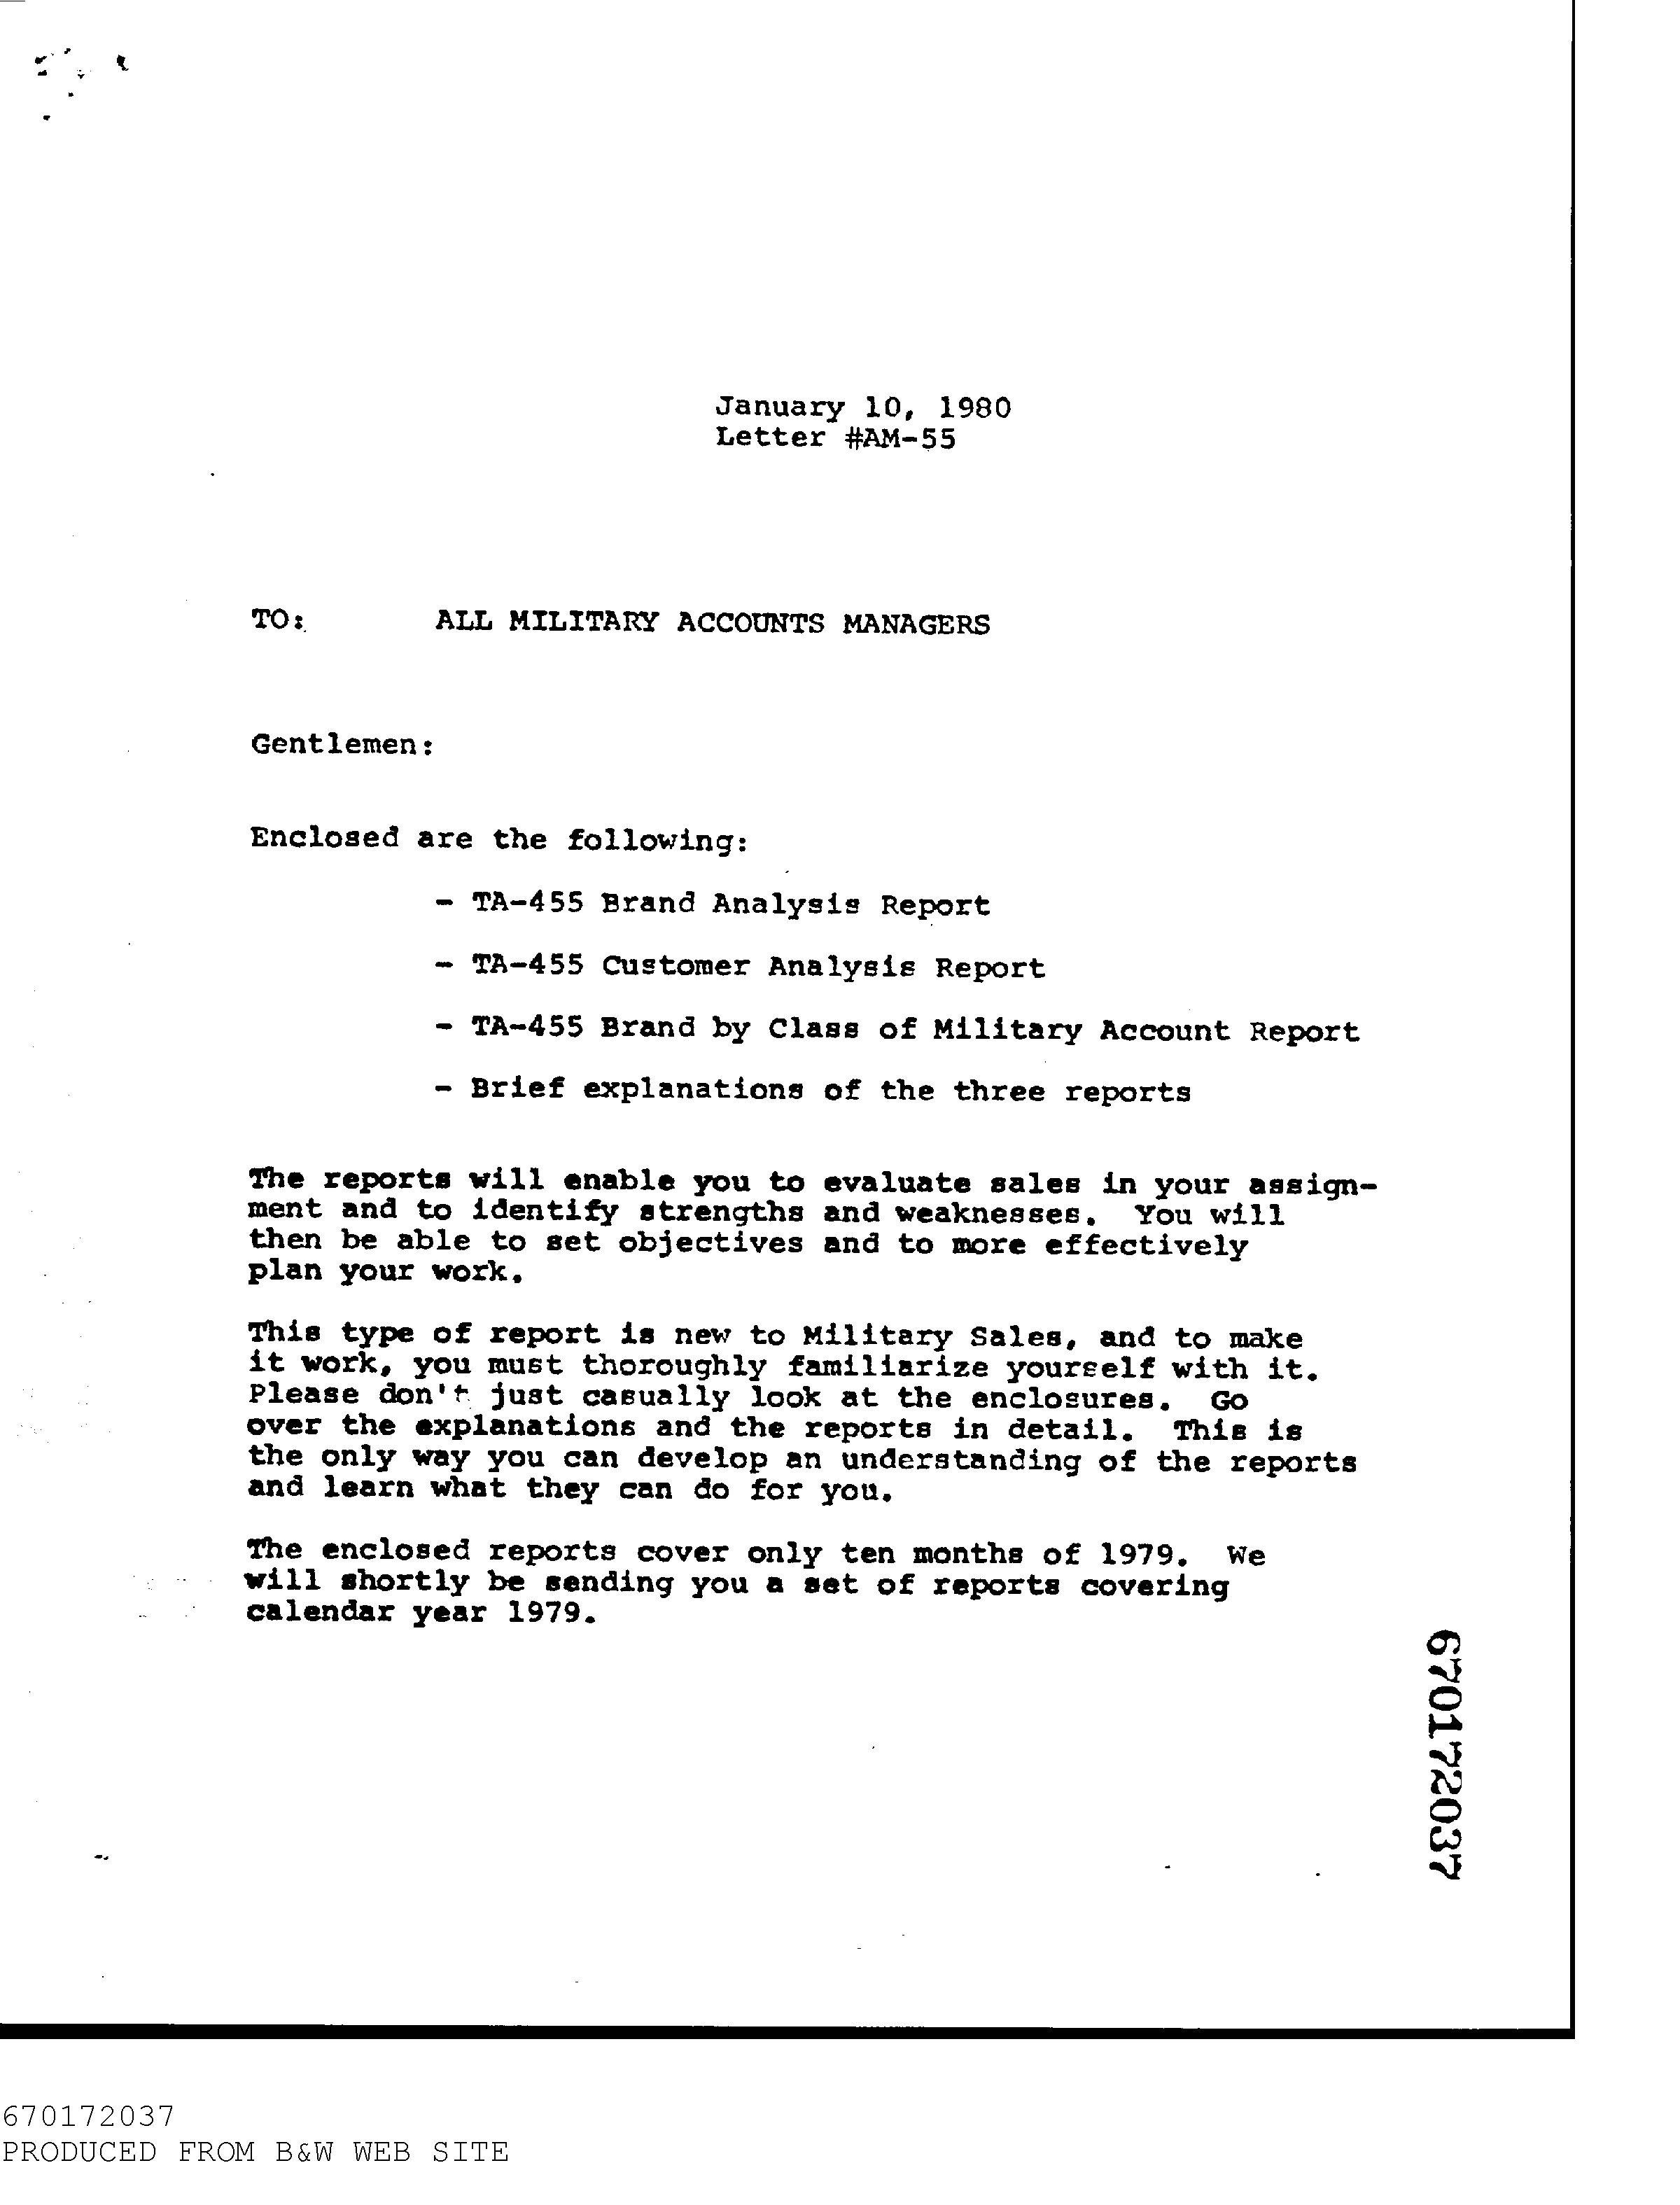


    Image #1:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/document_classification/samplecv.jpg
    Resolution: 72 dpi
    Width: 2544 px
    Height: 3296 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


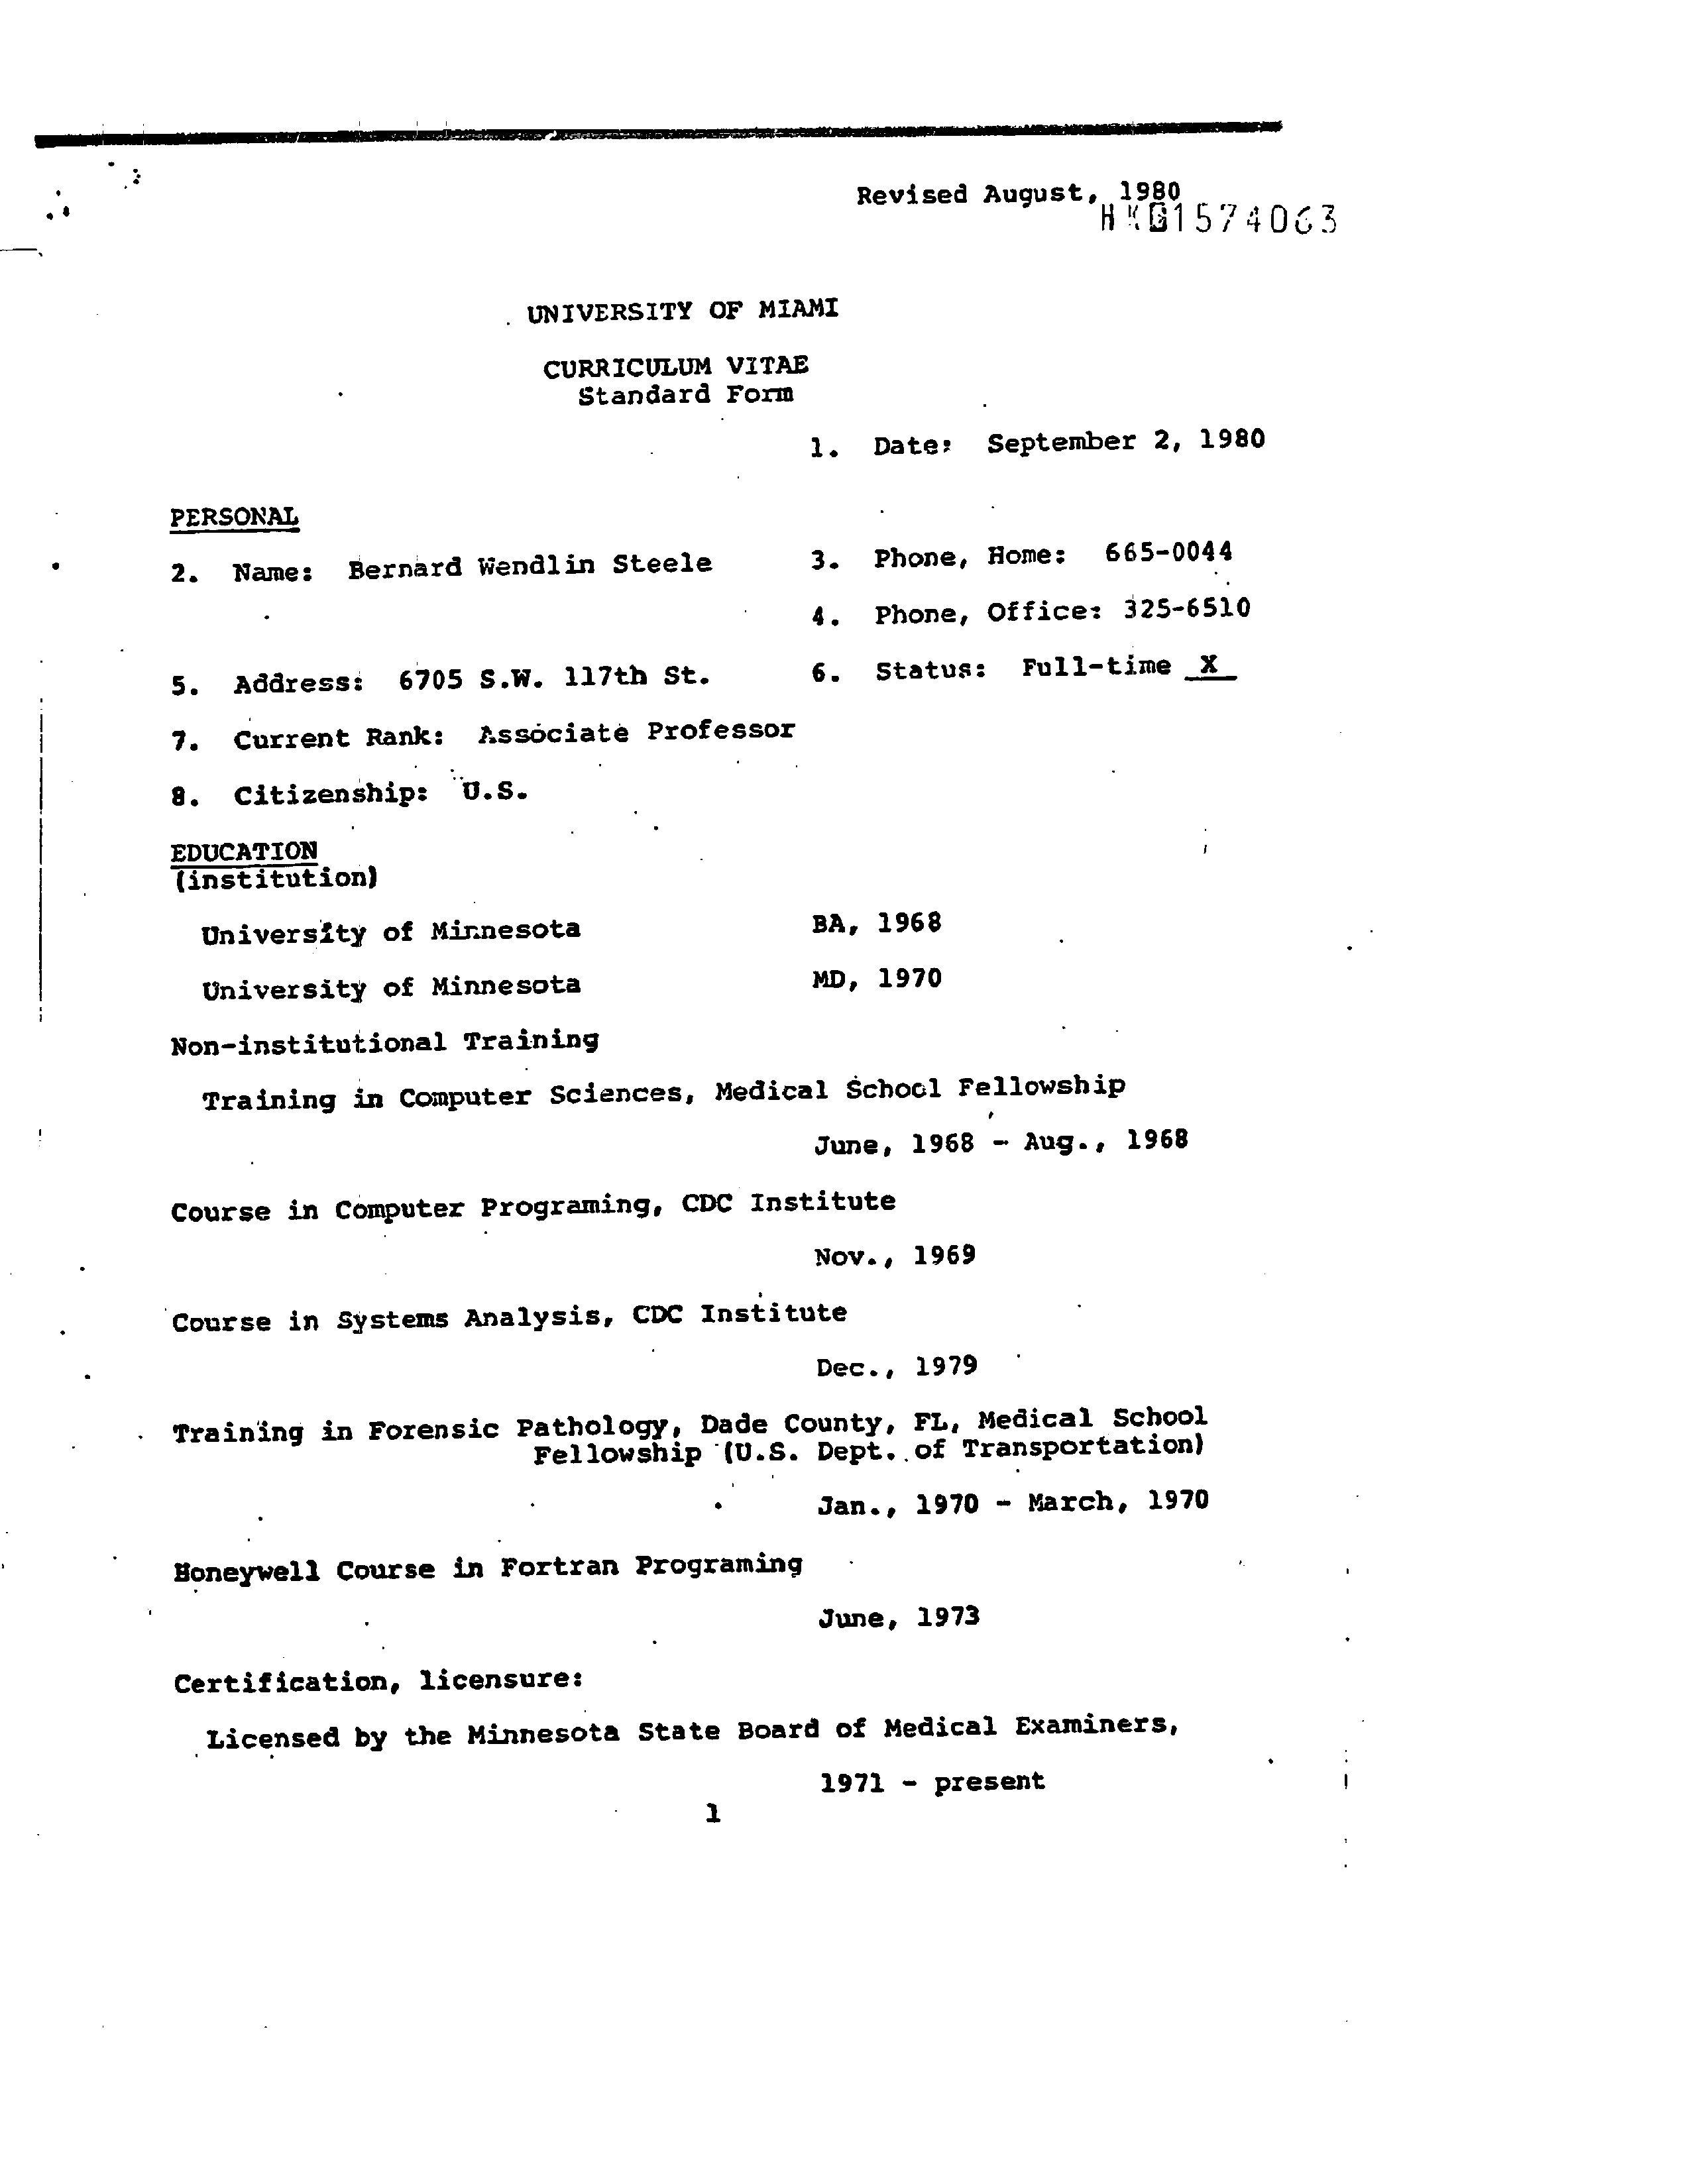


    Image #2:
    Origin: file:/home/jose/.local/lib/python3.8/site-packages/sparkocr/resources/ocr/images/document_classification/layout_paper.png
    Resolution: 143 dpi
    Width: 1120 px
    Height: 1434 px
    Mode: ImageType.TYPE_BYTE_GRAY
    Number of channels: 1


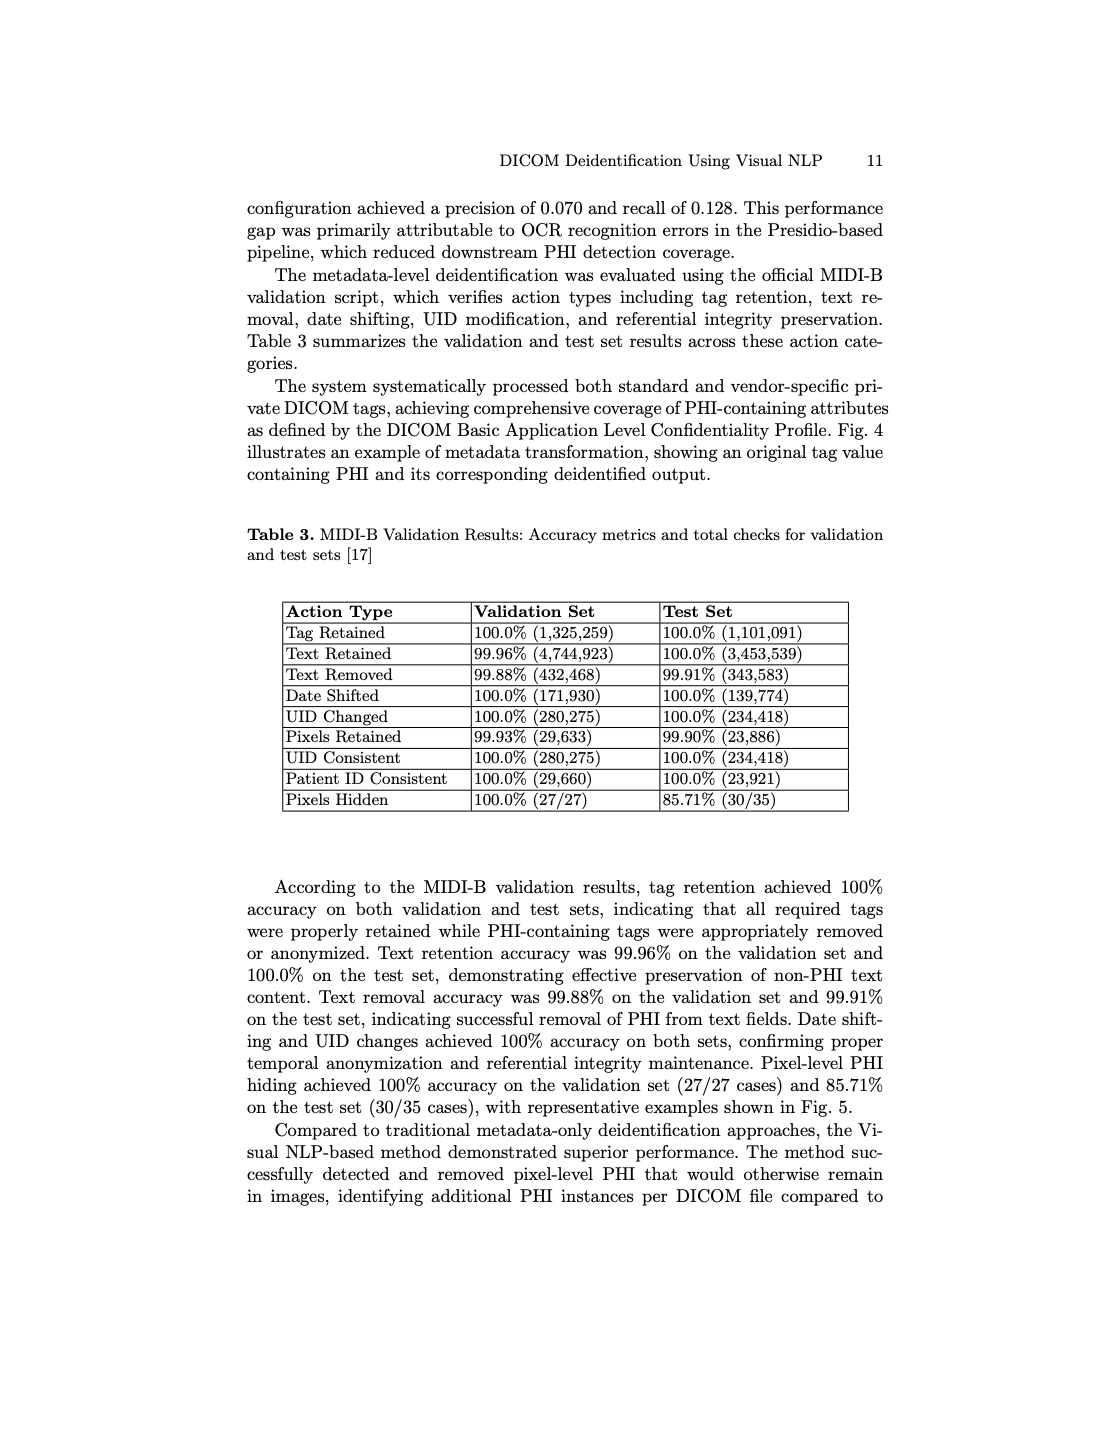

In [9]:
# NBVAL_SKIP
from sparkocr.utils import display_images
display_images(BinaryToImage().transform(img_example_df), field='image')

## Run OCR pipelines
Here I repartition so all pages from the same partition end up in the same PDF, when each page comes out of another PDF, pages are aggregated according to source file.

In [10]:
result = pipeline().transform(img_example_df.repartition(1)).cache()

## Store results to pdf file

In [11]:
pdf = result.select("pdf_document").head().pdf_document
pdfFile = open("image_doc1.pdf", "wb")
pdfFile.write(pdf)
pdfFile.close()

## Display output as image PDF

In [12]:
display_pdf_file('image_doc1.pdf')

### Let's explore how grouping works - merge multiple pages into a single PDF
By default this works according to the source `path` of each PDF so multiple images coming from the same PDF will end up together. Here, instead, we will simulate some grouping by adding a special column with some value and telling ImageToPdf to use that to group the images.

In [13]:
# Read binary as image
binary_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("images")

# Run OCR and render results to PDF
image_to_pdf = ImageToPdf() \
    .setInputCol("images") \
    .setOutputCol("pdf_document")

In [14]:
from pyspark.sql.functions import lit
imgs = binary_to_image.transform(img_example_df).withColumn("origin", lit("someKeyToGroupThings"))

In [15]:
result = image_to_pdf.setOriginCol("origin").transform(imgs)
pdf = result.select("pdf_document").head().pdf_document
pdfFile = open("image_pdf_grouped.pdf", "wb")
pdfFile.write(pdf)
pdfFile.close()

In [16]:
display_pdf_file('image_pdf_grouped.pdf')